<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/02_MY_PORTFOLIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting | My Portfolio

## How is my portfolio doing?

This is the **ongoing home/terminal** for an existing customer. It answers the most important questions first: **What is my portfolio worth? How is it performing? What is its estimated target value? How healthy and concentrated is it?**

The notebook then provides detailed holdings for drill-down. Decision and opportunity analysis live in the next notebooks rather than being repeated here.

> **Customer journey:** Monitor my portfolio → understand health → inspect holdings.

## Customer dashboard

### Primary KPIs

- Current Value
- Deployed Value
- CAGR / XIRR
- Target Value
- Target Profit (₹ + %)

### Portfolio health

- In Portfolio Health
- Core Allocation
- Legacy Allocation
- Out of Universe Allocation

### Concentration

- Top-5
- Top-10
- Top-20

Deeper metrics such as FTT, RRR, Risk, Conviction and CumlRnk remain available in the holdings/decision views; they are intentionally not repeated as headline KPIs here.

In [1]:
!pip install -q ta pyxirr matplotlib plotly ipywidgets

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.4/532.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.1 MB/s eta 0:00:00


In [2]:
# 1. Environment & controls

from google.colab import drive
drive.mount("/content/drive")

import sys
PROJECT = "/content/drive/My Drive/quantvesting_v3"
MARKET_DATA_DIR = PROJECT + "/market_data"
PORTFOLIO_ID = input("Enter Portfolio ID (default: ankit): ").strip() or "ankit"
PORTFOLIO_DATA_DIR = PROJECT + f"/portfolio_data/{PORTFOLIO_ID}"
EOD_RUN = False

sys.path.insert(0, PROJECT + "/src")

from quantvesting import (
    Quantvesting, load_config, load_market_data, load_portfolio_data,
    create_run_id, PORTFOLIO_DISPLAY_COLUMNS,
)

RUN_ID = create_run_id()
config = load_config(PROJECT + "/config/strategy.yaml")
qv = Quantvesting(config)
market_data = load_market_data(MARKET_DATA_DIR)
portfolio_data = load_portfolio_data(PORTFOLIO_DATA_DIR, portfolio_id=PORTFOLIO_ID)

Mounted at /content/drive
Enter Portfolio ID (default: ankit): vinod


In [3]:
# 2. Run portfolio analysis
# EOD_RUN=False -> analysis only
# EOD_RUN=True  -> replace/create today's official IST snapshot
df_portfolio, portfolio_summary = qv.portfolio(
    market_data, portfolio_data=portfolio_data, eod=EOD_RUN,
    portfolio_id=PORTFOLIO_ID, run_id=RUN_ID,
)

In [4]:
# Load the current Quantvesting universe for classification only.
# Opportunity exploration itself is kept in 04_QUANTVESTING_OPPORTUNITIES.ipynb.
df_prospects = qv.prospects(
    market_data, portfolio_data=portfolio_data, include_portfolio=True,
    portfolio_id=PORTFOLIO_ID, run_id=RUN_ID,
)


## 3. Executive portfolio terminal

The terminal is deliberately the first analytical output. It is the customer's single point-in-time portfolio summary.

In [5]:
qv.display_terminal(
    portfolio_data=portfolio_data,
    df_portfolio=df_portfolio,
    df_prospects=df_prospects,
    portfolio_summary=portfolio_summary,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
    run_datetime=portfolio_summary.get("run_datetime"),
)

{'current': 542320.0,
 'deployed': 867500.0,
 'xirr': nan,
 'target_value': 933471.0,
 'target_profit': 391151.0,
 'target_profit_pct': 72.12549786104145,
 'portfolio_health_pct': 100.0,
 'portfolio_health_value': 542320.0,
 'core_allocation_pct': 100.0,
 'legacy_allocation_pct': 0.0,
 'out_of_universe_allocation_pct': nan,
 'out_of_universe_basis': 'unavailable',
 'top5_concentration_pct': 100.0,
 'top10_concentration_pct': 100.0,
 'top20_concentration_pct': 100.0,
 'pnl': -325180.0,
 'positions': 3,
 'prospects': 60,
 'weighted_remaining_upside_pct': 0.7212549786104145,
 'median_rrr': -0.47,
 'action_count': 0,
 'prospect_candidates': 0,
 'rotation_candidates': 0}

## 4. Portfolio composition and concentration

Use these views to understand where the money is allocated. Detailed decision metrics are intentionally deferred to `03_MY_DECISIONS.ipynb`.

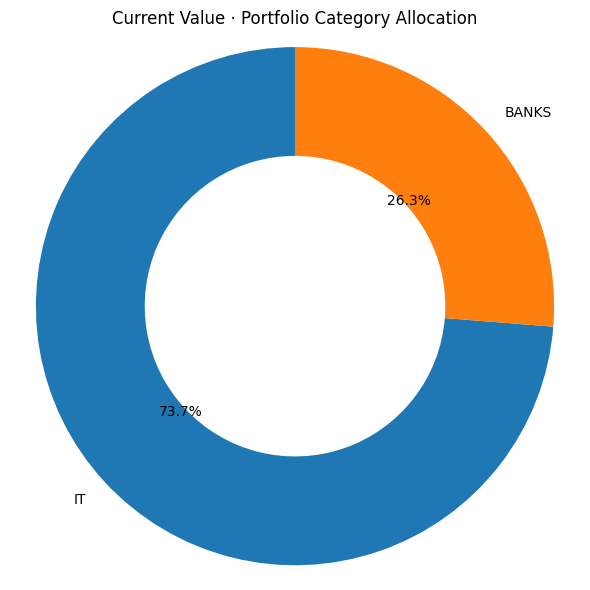

,Current
Category,
IT,399900.0
BANKS,142420.0


In [6]:
qv.display_health_chart(df_portfolio)
qv.display_portfolio_category_chart(
    df_portfolio,
    category_column="Category",
    value_column="Current",
    title="Current Value · Portfolio Category Allocation",
)

## 5. Holdings drill-down

The full analytical holding view is retained here for transparency, but it is not presented as the first-level customer dashboard.

In [7]:
qv.display_dataframe(
    df_portfolio,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="CurrAlloc%",
    ascending=False,
)

,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
2,TCS,-0.69,-28.00,83.62,32.21,192660.0,-89600.0,230400.0,4230.71,-43.98,48.0,X-LC,11.08,2.0,-0.47,42.48,16.85,X40,ATH,IT
1,INFY,-0.03,-22.07,74.51,36.00,126294.0,-48000.0,169500.0,1972.00,-40.86,49.0,X-LC,13.67,3.0,-0.38,31.25,14.69,X40,NTT,IT
0,HDFCBANK,0.77,-56.84,50.68,-34.97,72178.0,-187580.0,142420.0,1073.00,-29.51,40.0,X-LC,12.92,26.0,-2.60,26.26,1.61,X40,BTT,BANKS


## What next?

- **03_MY_DECISIONS** — What deserves my attention?
- **04_QUANTVESTING_OPPORTUNITIES** — What opportunities does the framework currently identify?
- **05_MY_QUANTVESTING_JOURNEY** — How has my portfolio evolved over time?